Classes: ['kidney_normal', 'kidney_tumor']
Counts by split:
 label  kidney_normal  kidney_tumor
split                             
test             750           750
train           3499          3500
val              751           750


2025-10-17 21:14:43.765668: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 993 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:61:00.0, compute capability: 8.6
2025-10-17 21:14:43.768308: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 21964 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:a1:00.0, compute capability: 8.6
2025-10-17 21:14:43.770730: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 21964 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:e1:00.0, compute capability: 8.6


Epoch 1/20


2025-10-17 21:14:46.156839: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape incnn/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-10-17 21:14:56.401332: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 2220 of 6999
2025-10-17 21:15:06.419102: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 4742 of 6999
2025-10-17 21:15:16.387065: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 6509 of 6999
2025-10-17 21:15:18.795666: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] Shuffle buffer filled.
2025-10-17 21:15:19.992060: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2025-10-17 21:15:20.595388: I tensorflow/compiler/xla/stream_exe

874/875 [============================>.] - ETA: 0s - loss: 0.4298 - accuracy: 0.8023

2025-10-17 21:15:39.938510: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 730.70MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


875/875 [==============================] - 60s 24ms/step - loss: 0.4299 - accuracy: 0.8023 - val_loss: 2.0006 - val_accuracy: 0.5963
Epoch 2/20
875/875 [==============================] - 20s 19ms/step - loss: 0.2852 - accuracy: 0.8893 - val_loss: 0.2340 - val_accuracy: 0.9067
Epoch 3/20
875/875 [==============================] - 20s 19ms/step - loss: 0.2243 - accuracy: 0.9148 - val_loss: 0.2817 - val_accuracy: 0.8807
Epoch 4/20
875/875 [==============================] - 20s 19ms/step - loss: 0.1756 - accuracy: 0.9367 - val_loss: 0.1505 - val_accuracy: 0.9580
Epoch 5/20
875/875 [==============================] - 20s 19ms/step - loss: 0.1561 - accuracy: 0.9450 - val_loss: 0.2513 - val_accuracy: 0.8907
Epoch 6/20
875/875 [==============================] - 20s 19ms/step - loss: 0.1232 - accuracy: 0.9524 - val_loss: 0.9062 - val_accuracy: 0.8354
Epoch 7/20
875/875 [==============================] - 20s 19ms/step - loss: 0.1216 - accuracy: 0.9570 - val_loss: 3.4245 - val_accuracy: 0.5916
Epo

<Figure size 650x550 with 0 Axes>

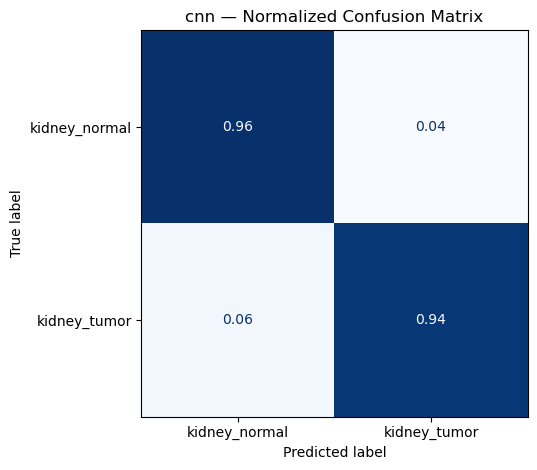

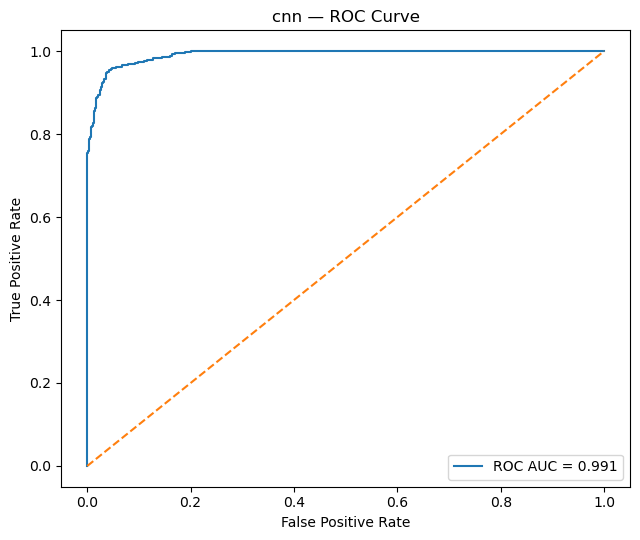

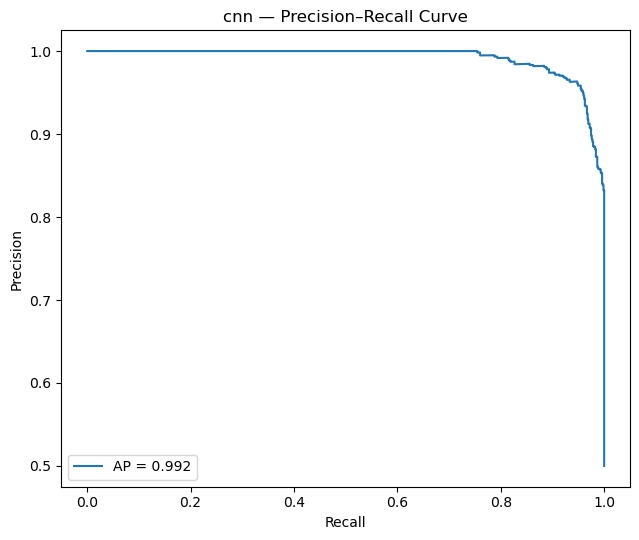

In [2]:
# CNN 
import os, random, pandas as pd, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils import shuffle

# ===============================
# Constants & Reproducibility
# ===============================
SEED = 1337
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE
random.seed(SEED); tf.random.set_seed(SEED)

# ===============================
# CSV manifest (fixed split)
# ===============================
CSV_PATH = "/home/jovyan/Independent/4KidneyCancer/kidney_cancer_split.csv"
BASE_DIR = None  # set a base folder only if your CSV has relative paths

manifest = pd.read_csv(CSV_PATH)

if BASE_DIR is not None:
    manifest["path"] = manifest["path"].apply(
        lambda p: p if os.path.isabs(p) else os.path.join(BASE_DIR, p)
    )

# Stable label mapping
labels_sorted = sorted(manifest["label"].unique())
label_to_int  = {l:i for i,l in enumerate(labels_sorted)}
int_to_label  = {v:k for k,v in label_to_int.items()}
num_classes   = len(labels_sorted)
print("Classes:", labels_sorted)

# Split dataframes
df_train = manifest[manifest["split"]=="train"].copy()
df_val   = manifest[manifest["split"]=="val"].copy()
df_test  = manifest[manifest["split"]=="test"].copy()

print("Counts by split:\n", manifest.groupby(["split","label"]).size().unstack(fill_value=0))

# ===============================
# tf.data from CSV (non-leaking)
# ===============================
def _decode(path):
    img = tf.io.read_file(path)
    # JPGs: decode_jpeg is a bit faster than generic decode_image
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, antialias=True)
    img = tf.cast(img, tf.float32)  # 0..255; we'll rescale in the model
    return img

def make_ds(df, split, batch_size=BATCH_SIZE, seed=SEED):
    if split == "train":
        df = shuffle(df, random_state=seed)
    paths  = df["path"].tolist()
    labels = [label_to_int[l] for l in df["label"]]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    def _load(p, y):
        return _decode(p), tf.cast(y, tf.int32)
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if split == "train":
        ds = ds.shuffle(buffer_size=len(paths), seed=seed, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_ds(df_train, "train")
val_ds   = make_ds(df_val,   "val")
test_ds  = make_ds(df_test,  "test")

# ===============================
# Data augmentation (train-only via model)
# ===============================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augment")

# ===============================
# Custom CNN 
# ===============================
def conv_block(x, filters, dropout=0.0):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    return x

def build_custom_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)  # keep preprocessing inside the model

    x = conv_block(x, 32,  dropout=0.10)
    x = conv_block(x, 64,  dropout=0.15)
    x = conv_block(x, 128, dropout=0.20)

    x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="cnn")

model = build_custom_cnn(IMG_SIZE + (3,), num_classes)

# =========================================
# Compile & Train
# =========================================
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor="val_accuracy"),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# ===== Evaluate on the held-out TEST set (matches second snippet practice) =====
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"{model.name}  |  Test acc: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")

# =========================================
# Evaluation: Confusion Matrix, Report, ROC & PR
# =========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

# 1) Collect ground-truth and model predictions on TEST set
y_true = []
for _, y in test_ds:
    y_true.extend(y.numpy())
y_true = np.array(y_true)

y_prob = model.predict(test_ds, verbose=0)            # (N, C) of probabilities
y_pred = np.argmax(y_prob, axis=1)

# 2) Classification report
print("\n=== Classification Report ===")
print(classification_report(
    y_true, y_pred,
    target_names=[int_to_label[i] for i in range(num_classes)],
    digits=4
))

# 3) Confusion Matrix (normalized)
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)), normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[int_to_label[i] for i in range(num_classes)])
plt.figure(figsize=(6.5, 5.5))
disp.plot(values_format=".2f", cmap="Blues", colorbar=False)
plt.title(f"{model.name} — Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# 4) ROC Curves (one-vs-rest for multiclass or standard for binary)
plt.figure(figsize=(6.5, 5.5))
if num_classes == 2:
    # Use probability of the positive class (class 1)
    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1], pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
else:
    # One-vs-rest
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    # Micro-average
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, label=f"micro-average ROC AUC = {roc_auc_micro:.3f}")

    # Per-class
    for i in range(num_classes):
        fpr_c, tpr_c, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc_c = auc(fpr_c, tpr_c)
        plt.plot(fpr_c, tpr_c, label=f"{int_to_label[i]} (AUC={roc_auc_c:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{model.name} — ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 5) Precision–Recall Curves (one-vs-rest for multiclass or standard for binary)
plt.figure(figsize=(6.5, 5.5))
if num_classes == 2:
    precision, recall, _ = precision_recall_curve(y_true, y_prob[:, 1], pos_label=1)
    ap = average_precision_score(y_true, y_prob[:, 1], pos_label=1)
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
else:
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    # Micro-average
    precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
    ap_micro = average_precision_score(y_true_bin, y_prob, average="micro")
    plt.plot(recall_micro, precision_micro, label=f"micro-average AP = {ap_micro:.3f}")

    # Per-class
    for i in range(num_classes):
        p_c, r_c, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        ap_c = average_precision_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(r_c, p_c, label=f"{int_to_label[i]} (AP={ap_c:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"{model.name} — Precision–Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

2025-10-17 21:56:46.687247: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-17 21:56:46.729964: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-17 21:56:47.422059: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Classes: ['kidney_normal', 'kidney_tumor']
Counts by split:
 label  kidney_normal  kidney_tumor
split                             
test             750           750
train           3499          3500
val              751           750


2025-10-17 21:56:50.394400: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9559 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:3d:00.0, compute capability: 7.5
2025-10-17 21:56:50.395922: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 9559 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:3e:00.0, compute capability: 7.5
2025-10-17 21:56:50.397309: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 9559 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:60:00.0, compute capability: 7.5


Epoch 1/20


2025-10-17 21:57:06.575225: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 4026 of 6999
2025-10-17 21:57:15.063464: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] Shuffle buffer filled.
2025-10-17 21:57:15.487020: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2025-10-17 21:57:16.088237: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x561c8851c930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-17 21:57:16.088274: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
2025-10-17 21:57:16.088280: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
2025-10-17 21:57:16.088285: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA 

875/875 [==============================] - 101s 78ms/step - loss: 0.7360 - accuracy: 0.8430 - val_loss: 1.0160 - val_accuracy: 0.6063
Epoch 2/20
875/875 [==============================] - 69s 76ms/step - loss: 0.4589 - accuracy: 0.8994 - val_loss: 1.7330 - val_accuracy: 0.7801
Epoch 3/20
875/875 [==============================] - 69s 76ms/step - loss: 0.3552 - accuracy: 0.9250 - val_loss: 6.2049 - val_accuracy: 0.4997
Epoch 4/20
875/875 [==============================] - 69s 76ms/step - loss: 0.2998 - accuracy: 0.9413 - val_loss: 7.0156 - val_accuracy: 0.5610
Epoch 5/20
875/875 [==============================] - 69s 76ms/step - loss: 0.2643 - accuracy: 0.9507 - val_loss: 5.5210 - val_accuracy: 0.5003
Epoch 6/20
875/875 [==============================] - 69s 76ms/step - loss: 0.2124 - accuracy: 0.9639 - val_loss: 0.8155 - val_accuracy: 0.6802
ResNetV2_29  |  Test acc: 0.8000  |  Test loss: 1.4167

=== Classification Report ===
               precision    recall  f1-score   support

kidn

<Figure size 650x550 with 0 Axes>

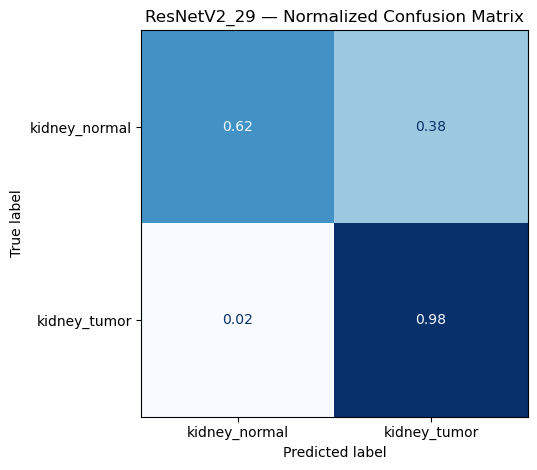

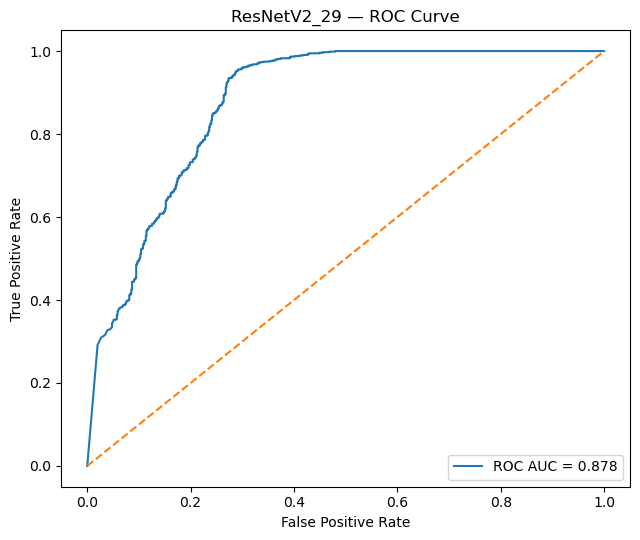

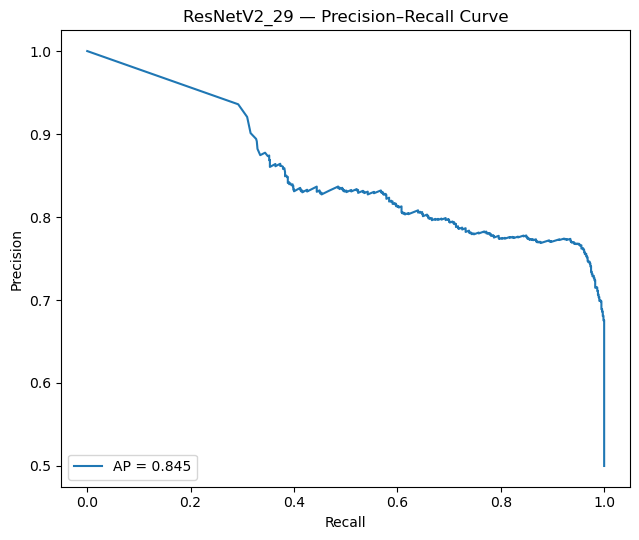

In [1]:
# RESNET

import os, random
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils import shuffle

# Extra imports for functional/regularizer symbols
from tensorflow.keras.regularizers import l2

# ===============================
# Constants & Reproducibility
# ===============================
SEED = 1337
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE
random.seed(SEED); tf.random.set_seed(SEED)

# ===============================
# CSV manifest (fixed split)
# ===============================
CSV_PATH = "/home/jovyan/Independent/4KidneyCancer/kidney_cancer_split.csv"
BASE_DIR = None  # set a base folder only if your CSV has relative paths

manifest = pd.read_csv(CSV_PATH)

if BASE_DIR is not None:
    manifest["path"] = manifest["path"].apply(
        lambda p: p if os.path.isabs(p) else os.path.join(BASE_DIR, p)
    )

# Stable label mapping
labels_sorted = sorted(manifest["label"].unique())
label_to_int  = {l:i for i,l in enumerate(labels_sorted)}
int_to_label  = {v:k for k,v in label_to_int.items()}
num_classes   = len(labels_sorted)
print("Classes:", labels_sorted)

# Split dataframes
df_train = manifest[manifest["split"]=="train"].copy()
df_val   = manifest[manifest["split"]=="val"].copy()
df_test  = manifest[manifest["split"]=="test"].copy()

print("Counts by split:\n", manifest.groupby(["split","label"]).size().unstack(fill_value=0))

# ===============================
# tf.data from CSV (non-leaking)
# ===============================
def _decode(path):
    img = tf.io.read_file(path)
    # JPGs: decode_jpeg is a bit faster than generic decode_image
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, antialias=True)
    img = tf.cast(img, tf.float32)  # 0..255; we'll rescale in the model
    return img

def make_ds(df, split, batch_size=BATCH_SIZE, seed=SEED):
    if split == "train":
        df = shuffle(df, random_state=seed)
    paths  = df["path"].tolist()
    labels = [label_to_int[l] for l in df["label"]]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    def _load(p, y):
        return _decode(p), tf.cast(y, tf.int32)
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if split == "train":
        ds = ds.shuffle(buffer_size=max(1024, len(paths)), seed=seed, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(df_train, "train")
val_ds   = make_ds(df_val,   "val")
test_ds  = make_ds(df_test,  "test")

# ===============================
# Data augmentation (train-only via model)
# ===============================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augment")

# ===============================
# ResNet building blocks
# ===============================
def resnet_layer(inputs,
                 num_filters=16,
                 kernel_size=3,
                 strides=1,
                 activation='relu',
                 batch_normalization=True,
                 conv_first=True):
    """A 2D Convolution-BN-Activation stack (order controlled by conv_first)."""
    conv = layers.Conv2D(
        num_filters,
        kernel_size=kernel_size,
        strides=strides,
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=l2(1e-4),
        use_bias=False
    )
    x = inputs
    if conv_first:
        x = conv(x)
        if batch_normalization:
            x = layers.BatchNormalization()(x)
        if activation is not None:
            x = layers.Activation(activation)(x)
    else:
        if batch_normalization:
            x = layers.BatchNormalization()(x)
        if activation is not None:
            x = layers.Activation(activation)(x)
        x = conv(x)
    return x

def resnet_v2(input_shape, depth, num_classes):
    """ResNet-v2 for CIFAR-style depth: depth = 9n + 2."""
    if (depth - 2) % 9 != 0:
        raise ValueError('depth should be 9n + 2 (e.g., 29, 56, 110).')

    num_filters_in = 16
    num_res_blocks = (depth - 2) // 9

    inputs = keras.Input(shape=input_shape)

    # In-model rescaling & augmentation
    z = layers.Rescaling(1./255)(inputs)   # now inputs are 0..1
    z = data_augmentation(z)               # active only during training

    # First conv (v2 uses BN-ReLU-Conv *inside* blocks, but we start with a conv-first)
    x = resnet_layer(inputs=z, num_filters=num_filters_in, conv_first=True)

    # Stages
    for stage in range(3):
        for res_block in range(num_res_blocks):
            activation = 'relu'
            batch_normalization = True
            strides = 1
            if stage == 0:
                num_filters_out = num_filters_in * 4
                if res_block == 0:
                    activation = None
                    batch_normalization = False
            else:
                num_filters_out = num_filters_in * 2
                if res_block == 0:
                    strides = 2

            # Bottleneck residual path: 1x1 -> 3x3 -> 1x1
            y = resnet_layer(inputs=x,
                             num_filters=num_filters_in,
                             kernel_size=1,
                             strides=strides,
                             activation=activation,
                             batch_normalization=batch_normalization,
                             conv_first=False)
            y = resnet_layer(inputs=y,
                             num_filters=num_filters_in,
                             kernel_size=3,
                             strides=1,
                             activation='relu',
                             batch_normalization=True,
                             conv_first=False)
            y = resnet_layer(inputs=y,
                             num_filters=num_filters_out,
                             kernel_size=1,
                             strides=1,
                             activation=None,
                             batch_normalization=True,
                             conv_first=False)

            # Projection for the shortcut on first block of each stage
            if res_block == 0:
                x = resnet_layer(inputs=x,
                                 num_filters=num_filters_out,
                                 kernel_size=1,
                                 strides=strides,
                                 activation=None,
                                 batch_normalization=False,
                                 conv_first=True)
            # Add
            x = layers.Add()([x, y])

        # Next stage doubles filters (handled via num_filters_out)
        num_filters_in = num_filters_out

    # Final BN -> ReLU
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Global average pooling and classifier head
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax', kernel_initializer='he_normal')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=f"ResNetV2_{depth}")
    return model

# Build model (depth=29 -> 9*3 + 2)
model = resnet_v2(input_shape=IMG_SIZE + (3,), depth=29, num_classes=num_classes)
#model.summary()

# =========================================
# Compile & Train
# =========================================
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor="val_accuracy"),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# =========================================
# Evaluate on the held-out TEST set
# =========================================
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"{model.name}  |  Test acc: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")

# =========================================
# Evaluation: Confusion Matrix, Report, ROC & PR
# =========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

# 1) Collect ground-truth and model predictions on TEST set
y_true = []
for _, y in test_ds:
    y_true.extend(y.numpy())
y_true = np.array(y_true)

y_prob = model.predict(test_ds, verbose=0)            # (N, C) of probabilities
y_pred = np.argmax(y_prob, axis=1)

# 2) Classification report
print("\n=== Classification Report ===")
print(classification_report(
    y_true, y_pred,
    target_names=[int_to_label[i] for i in range(num_classes)],
    digits=4
))

# 3) Confusion Matrix (normalized)
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)), normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[int_to_label[i] for i in range(num_classes)])
plt.figure(figsize=(6.5, 5.5))
disp.plot(values_format=".2f", cmap="Blues", colorbar=False)
plt.title(f"{model.name} — Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# 4) ROC Curves (one-vs-rest for multiclass or standard for binary)
plt.figure(figsize=(6.5, 5.5))
if num_classes == 2:
    # Use probability of the positive class (class 1)
    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1], pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
else:
    # One-vs-rest
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    # Micro-average
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, label=f"micro-average ROC AUC = {roc_auc_micro:.3f}")

    # Per-class
    for i in range(num_classes):
        fpr_c, tpr_c, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc_c = auc(fpr_c, tpr_c)
        plt.plot(fpr_c, tpr_c, label=f"{int_to_label[i]} (AUC={roc_auc_c:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{model.name} — ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 5) Precision–Recall Curves (one-vs-rest for multiclass or standard for binary)
plt.figure(figsize=(6.5, 5.5))
if num_classes == 2:
    precision, recall, _ = precision_recall_curve(y_true, y_prob[:, 1], pos_label=1)
    ap = average_precision_score(y_true, y_prob[:, 1], pos_label=1)
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
else:
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    # Micro-average
    precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
    ap_micro = average_precision_score(y_true_bin, y_prob, average="micro")
    plt.plot(recall_micro, precision_micro, label=f"micro-average AP = {ap_micro:.3f}")

    # Per-class
    for i in range(num_classes):
        p_c, r_c, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        ap_c = average_precision_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(r_c, p_c, label=f"{int_to_label[i]} (AP={ap_c:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"{model.name} — Precision–Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

Classes: ['kidney_normal', 'kidney_tumor']
Counts by split:
 label  kidney_normal  kidney_tumor
split                             
test             750           750
train           3499          3500
val              751           750
Epoch 1/20
875/875 [==============================] - 88s 89ms/step - loss: 7.4817 - accuracy: 0.4968 - val_loss: 4.3810 - val_accuracy: 0.4997
Epoch 2/20
875/875 [==============================] - 78s 86ms/step - loss: 4.4107 - accuracy: 0.5052 - val_loss: 3.9348 - val_accuracy: 0.4997
Epoch 3/20
875/875 [==============================] - 78s 86ms/step - loss: 5.3238 - accuracy: 0.5048 - val_loss: 4.0174 - val_accuracy: 0.4997
Epoch 4/20
875/875 [==============================] - 78s 86ms/step - loss: 3.6549 - accuracy: 0.4914 - val_loss: 3.3296 - val_accuracy: 0.4997
Epoch 5/20
875/875 [==============================] - 78s 87ms/step - loss: 3.0553 - accuracy: 0.4975 - val_loss: 2.7973 - val_accuracy: 0.5003
Epoch 6/20
875/875 [========================

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 650x550 with 0 Axes>

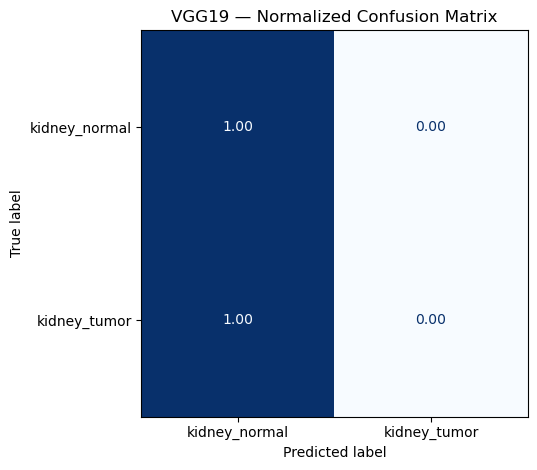

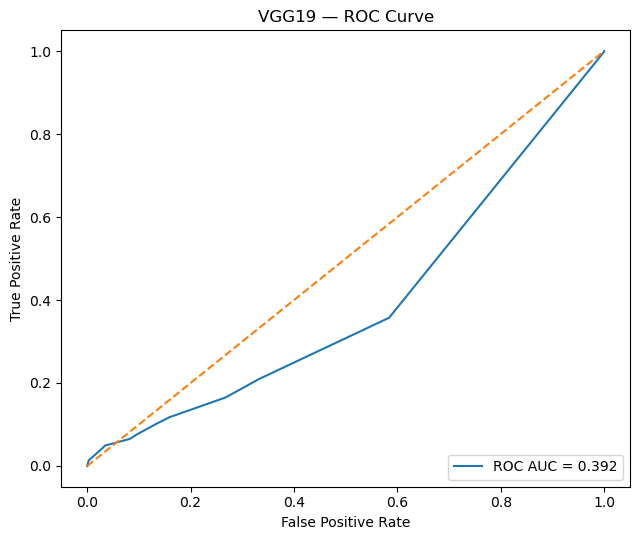

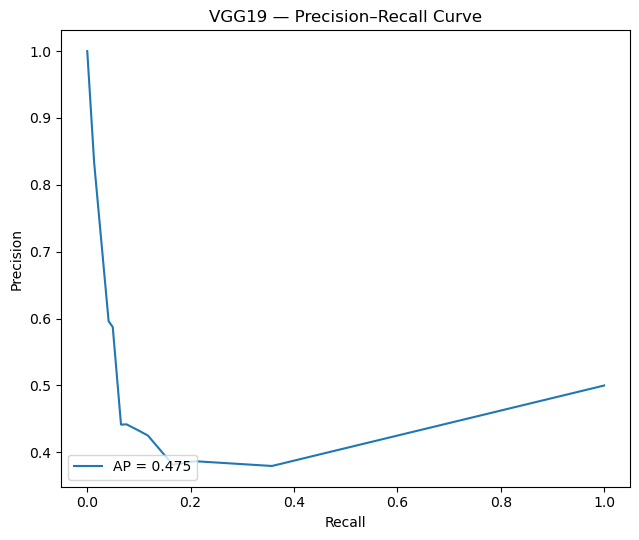

In [2]:
#VGG
import os, random, pandas as pd, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils import shuffle
from tensorflow.keras import layers, models, regularizers

# ===============================
# Constants & Reproducibility
# ===============================
SEED = 1337
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE
random.seed(SEED); tf.random.set_seed(SEED)

# ===============================
# CSV manifest (fixed split)
# ===============================
CSV_PATH = "/home/jovyan/Independent/4KidneyCancer/kidney_cancer_split.csv"
BASE_DIR = None  # set a base folder only if your CSV has relative paths

manifest = pd.read_csv(CSV_PATH)

if BASE_DIR is not None:
    manifest["path"] = manifest["path"].apply(
        lambda p: p if os.path.isabs(p) else os.path.join(BASE_DIR, p)
    )

# Stable label mapping
labels_sorted = sorted(manifest["label"].unique())
label_to_int  = {l:i for i,l in enumerate(labels_sorted)}
int_to_label  = {v:k for k,v in label_to_int.items()}
num_classes   = len(labels_sorted)
print("Classes:", labels_sorted)

# Split dataframes
df_train = manifest[manifest["split"]=="train"].copy()
df_val   = manifest[manifest["split"]=="val"].copy()
df_test  = manifest[manifest["split"]=="test"].copy()

print("Counts by split:\n", manifest.groupby(["split","label"]).size().unstack(fill_value=0))

# ===============================
# tf.data from CSV (non-leaking)
# ===============================
def _decode(path):
    img = tf.io.read_file(path)
    # JPGs: decode_jpeg is a bit faster than generic decode_image
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, antialias=True)
    img = tf.cast(img, tf.float32)  # 0..255; we'll rescale in the model
    return img

def make_ds(df, split, batch_size=BATCH_SIZE, seed=SEED):
    if split == "train":
        df = shuffle(df, random_state=seed)
    paths  = df["path"].tolist()
    labels = [label_to_int[l] for l in df["label"]]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    def _load(p, y):
        return _decode(p), tf.cast(y, tf.int32)
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if split == "train":
        ds = ds.shuffle(buffer_size=len(paths), seed=seed, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_ds(df_train, "train")
val_ds   = make_ds(df_val,   "val")
test_ds  = make_ds(df_test,  "test")

# ===============================
# Data augmentation (train-only via model)
# ===============================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augment")

# ===================================
# VGG-19 
# ===================================

def build_vgg19(input_shape, num_classes, weight_decay=5e-4, dropout=0.5):
    """
    Classic-ish VGG-19:
      - 3x3 conv (same), ReLU
      - MaxPool(2) after each block
      - FC: 4096 -> 4096 -> num_classes
    """
    L2 = regularizers.l2(weight_decay)

    def conv_block(x, filters, convs):
        for _ in range(convs):
            x = layers.Conv2D(
                filters, (3, 3), padding='same', activation='relu',
                kernel_regularizer=L2, kernel_initializer='he_normal'
            )(x)
        x = layers.MaxPooling2D((2, 2), strides=2)(x)  # pool AFTER all convs
        return x

    inputs = layers.Input(shape=input_shape)

    # (Optional) do aug in the model so train-only:
    x = layers.Rescaling(1./255)(inputs)  # your decoder outputs 0..255

    # VGG-19 conv config: [2,2,4,4,4] filters: [64,128,256,512,512]
    x = conv_block(x,  64, 2)  # Block 1
    x = conv_block(x, 128, 2)  # Block 2
    x = conv_block(x, 256, 4)  # Block 3
    x = conv_block(x, 512, 4)  # Block 4
    x = conv_block(x, 512, 4)  # Block 5

    # Classifier
    x = layers.Flatten()(x)
    x = layers.Dense(4096, activation='relu', kernel_regularizer=L2)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(4096, activation='relu', kernel_regularizer=L2)(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="VGG19")
    return model

model = build_vgg19(IMG_SIZE + (3,), num_classes)


# =========================================
# Compile & Train
# =========================================
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor="val_accuracy"),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# ===== Evaluate on the held-out TEST set (matches second snippet practice) =====
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"{model.name}  |  Test acc: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")

# =========================================
# Evaluation: Confusion Matrix, Report, ROC & PR
# =========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

# 1) Collect ground-truth and model predictions on TEST set
y_true = []
for _, y in test_ds:
    y_true.extend(y.numpy())
y_true = np.array(y_true)

y_prob = model.predict(test_ds, verbose=0)            # (N, C) of probabilities
y_pred = np.argmax(y_prob, axis=1)

# 2) Classification report
print("\n=== Classification Report ===")
print(classification_report(
    y_true, y_pred,
    target_names=[int_to_label[i] for i in range(num_classes)],
    digits=4
))

# 3) Confusion Matrix (normalized)
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)), normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[int_to_label[i] for i in range(num_classes)])
plt.figure(figsize=(6.5, 5.5))
disp.plot(values_format=".2f", cmap="Blues", colorbar=False)
plt.title(f"{model.name} — Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# 4) ROC Curves (one-vs-rest for multiclass or standard for binary)
plt.figure(figsize=(6.5, 5.5))
if num_classes == 2:
    # Use probability of the positive class (class 1)
    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1], pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
else:
    # One-vs-rest
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    # Micro-average
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, label=f"micro-average ROC AUC = {roc_auc_micro:.3f}")

    # Per-class
    for i in range(num_classes):
        fpr_c, tpr_c, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc_c = auc(fpr_c, tpr_c)
        plt.plot(fpr_c, tpr_c, label=f"{int_to_label[i]} (AUC={roc_auc_c:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{model.name} — ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 5) Precision–Recall Curves (one-vs-rest for multiclass or standard for binary)
plt.figure(figsize=(6.5, 5.5))
if num_classes == 2:
    precision, recall, _ = precision_recall_curve(y_true, y_prob[:, 1], pos_label=1)
    ap = average_precision_score(y_true, y_prob[:, 1], pos_label=1)
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
else:
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    # Micro-average
    precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
    ap_micro = average_precision_score(y_true_bin, y_prob, average="micro")
    plt.plot(recall_micro, precision_micro, label=f"micro-average AP = {ap_micro:.3f}")

    # Per-class
    for i in range(num_classes):
        p_c, r_c, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        ap_c = average_precision_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(r_c, p_c, label=f"{int_to_label[i]} (AP={ap_c:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"{model.name} — Precision–Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

Classes: ['kidney_normal', 'kidney_tumor']
Counts by split:
 label  kidney_normal  kidney_tumor
split                             
test             750           750
train           3499          3500
val              751           750
Epoch 1/20
875/875 [==============================] - 45s 38ms/step - loss: 0.9690 - main_loss: 0.6248 - aux1_loss: 0.5612 - aux2_loss: 0.5860 - main_accuracy: 0.6354 - val_loss: 0.7980 - val_main_loss: 0.5441 - val_aux1_loss: 0.4067 - val_aux2_loss: 0.4395 - val_main_accuracy: 0.7328
Epoch 2/20
875/875 [==============================] - 33s 35ms/step - loss: 0.5486 - main_loss: 0.3650 - aux1_loss: 0.2946 - aux2_loss: 0.3176 - main_accuracy: 0.8497 - val_loss: 0.7235 - val_main_loss: 0.5051 - val_aux1_loss: 0.3356 - val_aux2_loss: 0.3923 - val_main_accuracy: 0.7588
Epoch 3/20
875/875 [==============================] - 33s 35ms/step - loss: 0.2480 - main_loss: 0.1652 - aux1_loss: 0.1371 - aux2_loss: 0.1389 - main_accuracy: 0.9381 - val_loss: 0.1476 - val_

<Figure size 650x550 with 0 Axes>

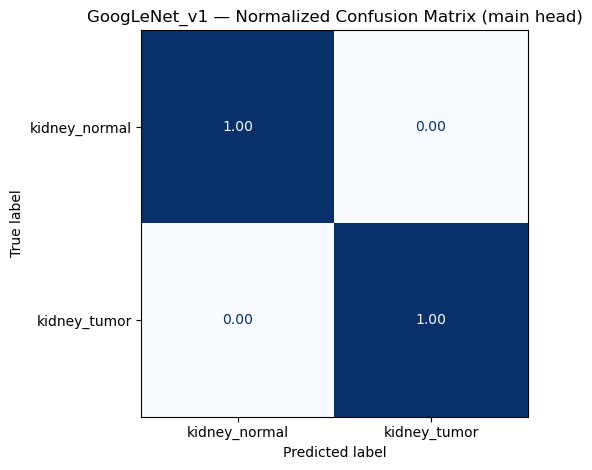

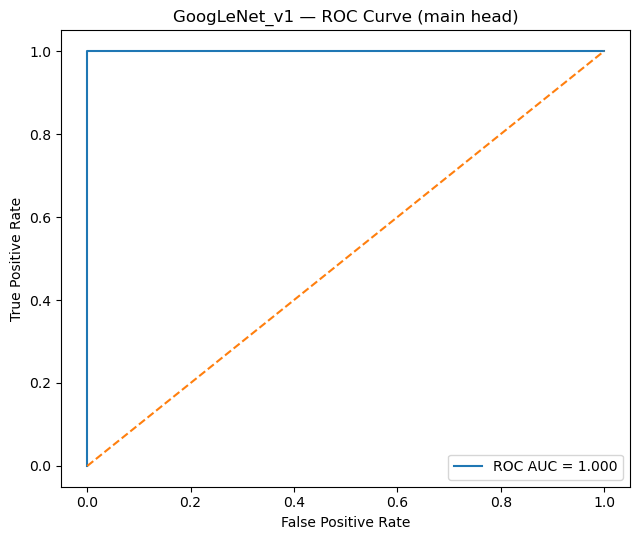

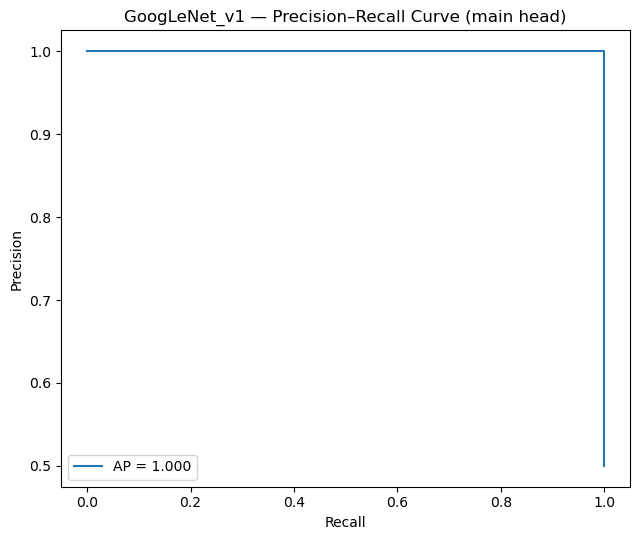

In [3]:
# GoogLeNet
import tensorflow as tf
from tensorflow.keras import layers, models
import os, random, pandas as pd, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils import shuffle
from tensorflow.keras import layers, models, regularizers

# ===============================
# Constants & Reproducibility
# ===============================
SEED = 1337
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE
random.seed(SEED); tf.random.set_seed(SEED)

# ===============================
# CSV manifest (fixed split)
# ===============================
CSV_PATH = "/home/jovyan/Independent/4KidneyCancer/kidney_cancer_split.csv"
BASE_DIR = None  # set a base folder only if your CSV has relative paths

manifest = pd.read_csv(CSV_PATH)

if BASE_DIR is not None:
    manifest["path"] = manifest["path"].apply(
        lambda p: p if os.path.isabs(p) else os.path.join(BASE_DIR, p)
    )

# Stable label mapping
labels_sorted = sorted(manifest["label"].unique())
label_to_int  = {l:i for i,l in enumerate(labels_sorted)}
int_to_label  = {v:k for k,v in label_to_int.items()}
num_classes   = len(labels_sorted)
print("Classes:", labels_sorted)

# Split dataframes
df_train = manifest[manifest["split"]=="train"].copy()
df_val   = manifest[manifest["split"]=="val"].copy()
df_test  = manifest[manifest["split"]=="test"].copy()

print("Counts by split:\n", manifest.groupby(["split","label"]).size().unstack(fill_value=0))

# ===============================
# tf.data from CSV (non-leaking)
# ===============================
def _decode(path):
    img = tf.io.read_file(path)
    # JPGs: decode_jpeg is a bit faster than generic decode_image
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, antialias=True)
    img = tf.cast(img, tf.float32)  # 0..255; we'll rescale in the model
    return img

def make_ds(df, split, batch_size=BATCH_SIZE, seed=SEED):
    if split == "train":
        df = shuffle(df, random_state=seed)
    paths  = df["path"].tolist()
    labels = [label_to_int[l] for l in df["label"]]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    def _load(p, y):
        return _decode(p), tf.cast(y, tf.int32)
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if split == "train":
        ds = ds.shuffle(buffer_size=len(paths), seed=seed, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_ds(df_train, "train")
val_ds   = make_ds(df_val,   "val")
test_ds  = make_ds(df_test,  "test")

# ===============================
# Data augmentation (train-only via model)
# ===============================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augment")

# =========================================================
# Helper: Conv -> ReLU
# =========================================================
def conv_relu(x, filters, kernel_size, strides=1, padding='same'):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding=padding,
                      activation='relu', kernel_initializer='he_normal')(x)
    return x

# =========================================================
# Local Response Normalization
# =========================================================
class LRN(layers.Layer):
    def call(self, x):
        return tf.nn.local_response_normalization(x)

# =========================================================
# Inception Module
# =========================================================
def inception_module(x, f1, f3r, f3, f5r, f5, fpool):
    b1 = conv_relu(x, f1, 1)
    b2 = conv_relu(x, f3r, 1); b2 = conv_relu(b2, f3, 3)
    b3 = conv_relu(x, f5r, 1); b3 = conv_relu(b3, f5, 5)
    b4 = layers.MaxPooling2D(3, strides=1, padding='same')(x)
    b4 = conv_relu(b4, fpool, 1)
    return layers.Concatenate()([b1, b2, b3, b4])

# =========================================================
# Auxiliary Classifier
# =========================================================
def auxiliary_classifier(x, num_classes, name=None):
    y = layers.AveragePooling2D(5, strides=3)(x)
    y = conv_relu(y, 128, 1)
    y = layers.Flatten()(y)
    y = layers.Dense(1024, activation='relu')(y)
    y = layers.Dropout(0.7)(y)
    y = layers.Dense(num_classes, activation='softmax', name=name)(y)
    return y

# =========================================================
# Build GoogLeNet v1
# =========================================================
def build_googlenet(input_shape=(224,224,3), num_classes=2):
    inputs = layers.Input(shape=input_shape)

    # Stem
    x = conv_relu(inputs, 64, 7, strides=2)
    x = LRN()(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)
    x = conv_relu(x, 64, 1)
    x = conv_relu(x, 192, 3)
    x = LRN()(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    # Inception 3a–3b
    x = inception_module(x, 64, 96, 128, 16, 32, 32)
    x = inception_module(x, 128, 128, 192, 32, 96, 64)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    # Inception 4a–4e
    x = inception_module(x, 192, 96, 208, 16, 48, 64)
    aux1 = auxiliary_classifier(x, num_classes, name='aux1')
    x = inception_module(x, 160, 112, 224, 24, 64, 64)
    x = inception_module(x, 128, 128, 256, 24, 64, 64)
    x = inception_module(x, 112, 144, 288, 32, 64, 64)
    aux2 = auxiliary_classifier(x, num_classes, name='aux2')
    x = inception_module(x, 256, 160, 320, 32, 128, 128)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    # Inception 5a–5b
    x = inception_module(x, 256, 160, 320, 32, 128, 128)
    x = inception_module(x, 384, 192, 384, 48, 128, 128)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    main_out = layers.Dense(num_classes, activation='softmax', name='main')(x)

    return models.Model(inputs, [main_out, aux1, aux2], name="GoogLeNet_v1")

# =========================================================
# Compile, Train, Evaluate
# =========================================================
model = build_googlenet(input_shape=IMG_SIZE + (3,), num_classes=num_classes)

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss={
        'main': tf.keras.losses.SparseCategoricalCrossentropy(),
        'aux1': tf.keras.losses.SparseCategoricalCrossentropy(),
        'aux2': tf.keras.losses.SparseCategoricalCrossentropy(),
    },
    loss_weights={'main': 1.0, 'aux1': 0.3, 'aux2': 0.3},
    metrics={'main': ['accuracy']}
)

#model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor="val_main_accuracy")
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# --- Evaluate on the test set (main head) ---
results = model.evaluate(test_ds, return_dict=True)
print(f"\nGoogLeNet_v1  |  Test accuracy: {results['main_accuracy']:.4f}")
#print(f"{model.name}  |  Test acc: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")

# =========================================
# Evaluation (use MAIN head only)
# =========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

# 1) Ground-truth labels
y_true = []
for _, y in test_ds:
    y_true.extend(y.numpy())
y_true = np.array(y_true)

# 2) Predictions (main head only)
pred_outputs = model.predict(test_ds, verbose=0)
# GoogLeNet returns [main_probs, aux1_probs, aux2_probs]
y_prob = pred_outputs[0] if isinstance(pred_outputs, (list, tuple)) else pred_outputs
y_pred = np.argmax(y_prob, axis=1)

print(f"Shapes — y_true: {y_true.shape}, y_prob(main): {y_prob.shape}, y_pred: {y_pred.shape}")

# 3) Classification report
print("\n=== Classification Report (main head) ===")
print(classification_report(
    y_true, y_pred,
    target_names=[int_to_label[i] for i in range(num_classes)],
    digits=4
))

# 4) Confusion Matrix (normalized)
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)), normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[int_to_label[i] for i in range(num_classes)])
plt.figure(figsize=(6.5, 5.5))
disp.plot(values_format=".2f", cmap="Blues", colorbar=False)
plt.title(f"{model.name} — Normalized Confusion Matrix (main head)")
plt.tight_layout()
plt.show()

# 5) ROC Curve
plt.figure(figsize=(6.5, 5.5))
if num_classes == 2:
    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1], pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
else:
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, label=f"micro-average ROC AUC = {roc_auc_micro:.3f}")
    for i in range(num_classes):
        fpr_c, tpr_c, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc_c = auc(fpr_c, tpr_c)
        plt.plot(fpr_c, tpr_c, label=f"{int_to_label[i]} (AUC={roc_auc_c:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"{model.name} — ROC Curve (main head)")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

# 6) Precision–Recall Curve
plt.figure(figsize=(6.5, 5.5))
if num_classes == 2:
    precision, recall, _ = precision_recall_curve(y_true, y_prob[:, 1], pos_label=1)
    ap = average_precision_score(y_true, y_prob[:, 1], pos_label=1)
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
else:
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
    ap_micro = average_precision_score(y_true_bin, y_prob, average="micro")
    plt.plot(recall_micro, precision_micro, label=f"micro-average AP = {ap_micro:.3f}")
    for i in range(num_classes):
        p_c, r_c, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        ap_c = average_precision_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(r_c, p_c, label=f"{int_to_label[i]} (AP={ap_c:.3f})")

plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"{model.name} — Precision–Recall Curve (main head)")
plt.legend(loc="lower left"); plt.tight_layout(); plt.show()

Classes: ['kidney_normal', 'kidney_tumor']
Counts by split:
 label  kidney_normal  kidney_tumor
split                             
test             750           750
train           3499          3500
val              751           750
Epoch 1/20
875/875 [==============================] - 72s 42ms/step - loss: 0.3341 - accuracy: 0.8544 - val_loss: 0.3699 - val_accuracy: 0.8614
Epoch 2/20
875/875 [==============================] - 37s 39ms/step - loss: 0.1578 - accuracy: 0.9456 - val_loss: 0.1554 - val_accuracy: 0.9500
Epoch 3/20
875/875 [==============================] - 37s 39ms/step - loss: 0.0793 - accuracy: 0.9774 - val_loss: 0.1541 - val_accuracy: 0.9400
Epoch 4/20
875/875 [==============================] - 37s 39ms/step - loss: 0.0902 - accuracy: 0.9693 - val_loss: 0.0144 - val_accuracy: 0.9973
Epoch 5/20
875/875 [==============================] - 37s 39ms/step - loss: 0.0912 - accuracy: 0.9721 - val_loss: 0.0211 - val_accuracy: 0.9933
Epoch 6/20
875/875 [========================

<Figure size 650x550 with 0 Axes>

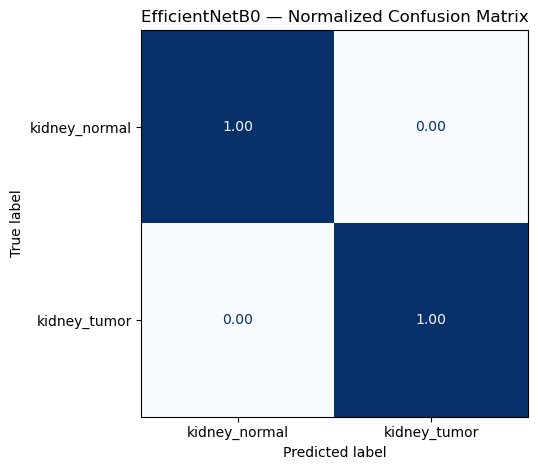

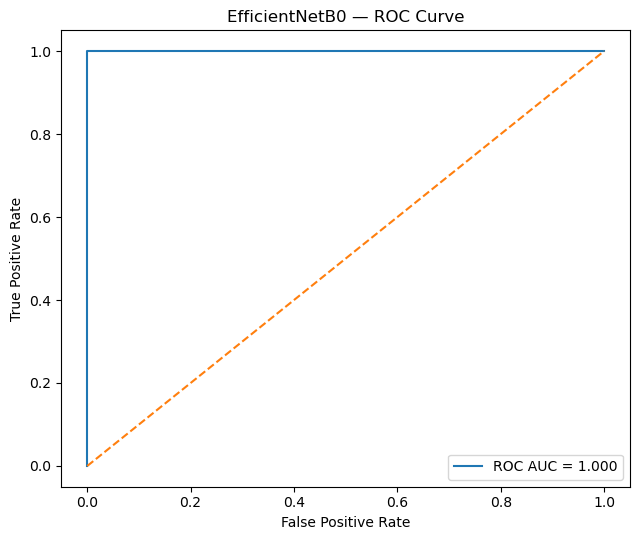

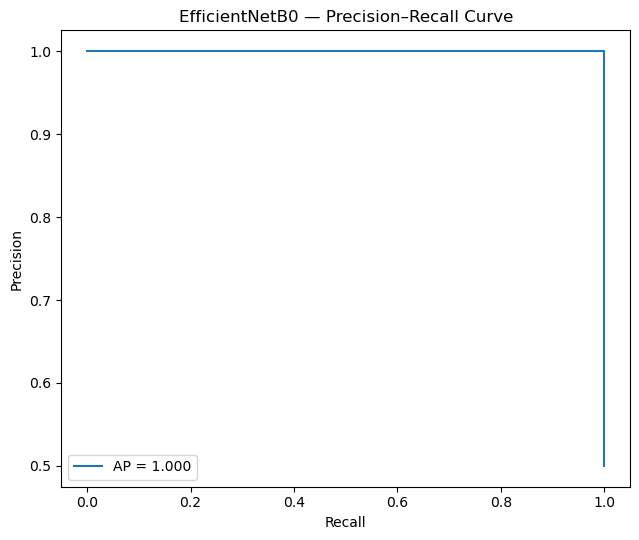

In [4]:
# EfficientNet
import os, random, pandas as pd, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils import shuffle
from tensorflow.keras import layers, models, regularizers

# ===============================
# Constants & Reproducibility
# ===============================
SEED = 1337
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE
random.seed(SEED); tf.random.set_seed(SEED)

# ===============================
# CSV manifest (fixed split)
# ===============================
CSV_PATH = "/home/jovyan/Independent/4KidneyCancer/kidney_cancer_split.csv"
BASE_DIR = None  # set a base folder only if your CSV has relative paths

manifest = pd.read_csv(CSV_PATH)

if BASE_DIR is not None:
    manifest["path"] = manifest["path"].apply(
        lambda p: p if os.path.isabs(p) else os.path.join(BASE_DIR, p)
    )

# Stable label mapping
labels_sorted = sorted(manifest["label"].unique())
label_to_int  = {l:i for i,l in enumerate(labels_sorted)}
int_to_label  = {v:k for k,v in label_to_int.items()}
num_classes   = len(labels_sorted)
print("Classes:", labels_sorted)

# Split dataframes
df_train = manifest[manifest["split"]=="train"].copy()
df_val   = manifest[manifest["split"]=="val"].copy()
df_test  = manifest[manifest["split"]=="test"].copy()

print("Counts by split:\n", manifest.groupby(["split","label"]).size().unstack(fill_value=0))

# ===============================
# tf.data from CSV (non-leaking)
# ===============================
def _decode(path):
    img = tf.io.read_file(path)
    # JPGs: decode_jpeg is a bit faster than generic decode_image
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, antialias=True)
    img = tf.cast(img, tf.float32)  # 0..255; we'll rescale in the model
    return img

def make_ds(df, split, batch_size=BATCH_SIZE, seed=SEED):
    if split == "train":
        df = shuffle(df, random_state=seed)
    paths  = df["path"].tolist()
    labels = [label_to_int[l] for l in df["label"]]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    def _load(p, y):
        return _decode(p), tf.cast(y, tf.int32)
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if split == "train":
        ds = ds.shuffle(buffer_size=len(paths), seed=seed, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_ds(df_train, "train")
val_ds   = make_ds(df_val,   "val")
test_ds  = make_ds(df_test,  "test")

# ===============================
# Data augmentation (train-only via model)
# ===============================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augment")

# EfficientNet 
def swish(x):
    return tf.nn.swish(x)

def drop_connect(inputs, drop_rate, training):
    if (not training) or drop_rate <= 0.0:
        return inputs
    keep_prob = 1.0 - drop_rate
    batch = tf.shape(inputs)[0]
    random_tensor = keep_prob + tf.random.uniform([batch, 1, 1, 1], dtype=inputs.dtype)
    binary_mask = tf.floor(random_tensor)
    outputs = (inputs / keep_prob) * binary_mask
    return outputs

class StochasticDepth(layers.Layer):
    def __init__(self, drop_rate=0.0, **kwargs):
        super().__init__(**kwargs)
        self.drop_rate = float(drop_rate)

    def call(self, x, training=None):
        return drop_connect(x, self.drop_rate, training)

# -------------------------------------------------------
# MBConv (Inverted Residual + SE)
# -------------------------------------------------------
def mbconv_block(
    x,
    out_channels,
    expand_ratio,
    kernel_size,
    stride,
    se_ratio=0.25,
    drop_rate=0.0,
    name=None,
):
    in_channels = x.shape[-1]
    shortcut = x
    prefix = "" if name is None else name + "/"

    # Expansion
    expanded_channels = int(in_channels * expand_ratio)
    if expand_ratio != 1:
        x = layers.Conv2D(expanded_channels, 1, padding="same", use_bias=False,
                          name=prefix + "expand_conv")(x)
        x = layers.BatchNormalization(name=prefix + "expand_bn")(x)
        x = layers.Activation(swish, name=prefix + "expand_swish")(x)

    # Depthwise
    x = layers.DepthwiseConv2D(
        kernel_size, strides=stride, padding="same", use_bias=False,
        name=prefix + "dwconv")(x)
    x = layers.BatchNormalization(name=prefix + "bn")(x)
    x = layers.Activation(swish, name=prefix + "swish")(x)

    # Squeeze-and-Excitation
    # SE is computed on the *expanded* channels (paper §3.2)
    se_channels = max(1, int((x.shape[-1]) * se_ratio))
    se = layers.GlobalAveragePooling2D(name=prefix + "se_squeeze")(x)
    se = layers.Reshape((1, 1, x.shape[-1]), name=prefix + "se_reshape")(se)
    se = layers.Conv2D(se_channels, 1, activation=swish,
                       name=prefix + "se_reduce")(se)
    se = layers.Conv2D(x.shape[-1], 1, activation="sigmoid",
                       name=prefix + "se_expand")(se)
    x = layers.Multiply(name=prefix + "se_excite")([x, se])

    # Projection
    x = layers.Conv2D(out_channels, 1, padding="same", use_bias=False,
                      name=prefix + "project_conv")(x)
    x = layers.BatchNormalization(name=prefix + "project_bn")(x)

    # Skip + stochastic depth
    if stride == 1 and in_channels == out_channels:
        if drop_rate and drop_rate > 0:
            x = StochasticDepth(drop_rate, name=prefix + "stochastic_depth")(x)
        x = layers.Add(name=prefix + "add")([x, shortcut])
    return x

# -------------------------------------------------------
# EfficientNet-B0 builder
# (canonical strides/resolutions: 224→112→56→28→14→14→7→7)
# -------------------------------------------------------
def build_efficientnet_b0(input_shape=(224, 224, 3), num_classes=1000,
                          drop_rate=0.2,  # head dropout
                          drop_connect_rate=0.2,  # linearly scaled across blocks
                          include_top=True):
    """
    Args:
        input_shape: (H, W, 3), typically (224,224,3)
        num_classes: number of classes for classification head
        drop_rate: dropout before final Dense
        drop_connect_rate: max stochastic depth rate; linearly decays from 0 → this value
        include_top: if False, returns global pooled features instead of Dense
    """
    inputs = keras.Input(shape=input_shape)

    # Optional: same normalization EfficientNet used during training (TF/TPU setups vary).
    # Here we keep it simple with [0,1] scaling.
    x = layers.Rescaling(1./255.0, name="rescale")(inputs)

    # Stem
    x = layers.Conv2D(32, 3, strides=2, padding="same", use_bias=False, name="stem_conv")(x)  # 224→112
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.Activation(swish, name="stem_swish")(x)

    # Block configuration for B0 (r = repeats)
    # (expand, out_c, k, s, r)
    cfgs = [
        # Stage 1
        (1,   16, 3, 1, 1),  # MBConv1, k3, stride1, r=1
        # Stage 2
        (6,   24, 3, 2, 2),  # MBConv6, k3, stride2, r=2
        # Stage 3
        (6,   40, 5, 2, 2),  # MBConv6, k5, stride2, r=2
        # Stage 4
        (6,   80, 3, 2, 3),  # MBConv6, k3, stride2, r=3
        # Stage 5
        (6,  112, 5, 1, 3),  # MBConv6, k5, stride1, r=3
        # Stage 6
        (6,  192, 5, 2, 4),  # MBConv6, k5, stride2, r=4
        # Stage 7
        (6,  320, 3, 1, 1),  # MBConv6, k3, stride1, r=1
    ]

    total_blocks = sum(r for *_, r in cfgs)
    block_id = 0

    for i, (t, c, k, s, r) in enumerate(cfgs):
        for j in range(r):
            stride = s if j == 0 else 1
            # linearly scale drop_connect per block (paper §3.4)
            dc = drop_connect_rate * float(block_id) / total_blocks
            x = mbconv_block(
                x,
                out_channels=c,
                expand_ratio=t,
                kernel_size=k,
                stride=stride,
                se_ratio=0.25,
                drop_rate=dc,
                name=f"blocks/{i+1}_{j+1}",
            )
            block_id += 1

    # Head
    x = layers.Conv2D(1280, 1, padding="same", use_bias=False, name="head_conv")(x)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Activation(swish, name="head_swish")(x)

    x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
    if include_top:
        if drop_rate and drop_rate > 0:
            x = layers.Dropout(drop_rate, name="top_dropout")(x)
        outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)
    else:
        outputs = x

    return keras.Model(inputs, outputs, name="EfficientNetB0")


model = build_efficientnet_b0(input_shape=IMG_SIZE + (3,), num_classes=num_classes)

# =========================================
# Compile & Train
# =========================================
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor="val_accuracy"),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# ===== Evaluate on the held-out TEST set (matches second snippet practice) =====
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"{model.name}  |  Test acc: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")

# =========================================
# Evaluation: Confusion Matrix, Report, ROC & PR
# =========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

# 1) Collect ground-truth and model predictions on TEST set
y_true = []
for _, y in test_ds:
    y_true.extend(y.numpy())
y_true = np.array(y_true)

y_prob = model.predict(test_ds, verbose=0)            # (N, C) of probabilities
y_pred = np.argmax(y_prob, axis=1)

# 2) Classification report
print("\n=== Classification Report ===")
print(classification_report(
    y_true, y_pred,
    target_names=[int_to_label[i] for i in range(num_classes)],
    digits=4
))

# 3) Confusion Matrix (normalized)
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)), normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[int_to_label[i] for i in range(num_classes)])
plt.figure(figsize=(6.5, 5.5))
disp.plot(values_format=".2f", cmap="Blues", colorbar=False)
plt.title(f"{model.name} — Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# 4) ROC Curves (one-vs-rest for multiclass or standard for binary)
plt.figure(figsize=(6.5, 5.5))
if num_classes == 2:
    # Use probability of the positive class (class 1)
    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1], pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
else:
    # One-vs-rest
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    # Micro-average
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, label=f"micro-average ROC AUC = {roc_auc_micro:.3f}")

    # Per-class
    for i in range(num_classes):
        fpr_c, tpr_c, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc_c = auc(fpr_c, tpr_c)
        plt.plot(fpr_c, tpr_c, label=f"{int_to_label[i]} (AUC={roc_auc_c:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{model.name} — ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 5) Precision–Recall Curves (one-vs-rest for multiclass or standard for binary)
plt.figure(figsize=(6.5, 5.5))
if num_classes == 2:
    precision, recall, _ = precision_recall_curve(y_true, y_prob[:, 1], pos_label=1)
    ap = average_precision_score(y_true, y_prob[:, 1], pos_label=1)
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
else:
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    # Micro-average
    precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
    ap_micro = average_precision_score(y_true_bin, y_prob, average="micro")
    plt.plot(recall_micro, precision_micro, label=f"micro-average AP = {ap_micro:.3f}")

    # Per-class
    for i in range(num_classes):
        p_c, r_c, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        ap_c = average_precision_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(r_c, p_c, label=f"{int_to_label[i]} (AP={ap_c:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"{model.name} — Precision–Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()
